## 1. Import Library

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style("whitegrid")

## 2. Load Dataset

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/iMaIrsdyh/KarimahIrsyadiyah_2411533018_ML2526/main/PRAKTIKUM%205/titanic/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Praproses Data

In [ ]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

X = df.drop(columns=["Survived"])
y = df["Survived"]

# Identifikasi fitur numerik dan kategorikal
numeric_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


## 4. Pipeline Preprocessing dan Model

In [21]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

## 5. K-Fold Cross Validation

In [22]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    model,
    X,
    y,
    cv=kf,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    return_train_score=False
)

results = pd.DataFrame({
    "Accuracy": scores["test_accuracy"],
    "Precision": scores["test_precision"],
    "Recall": scores["test_recall"],
    "F1-score": scores["test_f1"],
    "ROC-AUC": scores["test_roc_auc"]
})

results.index = [f"Fold {i}" for i in range(1, len(results) + 1)]
results

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Fold 1,0.782123,0.720588,0.710145,0.715328,0.874111
Fold 2,0.803371,0.770492,0.691176,0.728682,0.850134
Fold 3,0.797753,0.796296,0.632353,0.704918,0.826671
Fold 4,0.780899,0.710145,0.720588,0.715328,0.826671
Fold 5,0.820225,0.776119,0.753623,0.764706,0.879404


## 6. Rata-rata dan Standar Deviasi Metrik

In [23]:
summary = pd.DataFrame({
    "Mean": results.mean(),
    "Std": results.std()
})

summary

,Mean,Std
Accuracy,0.796874,0.016287
Precision,0.754728,0.037374
Recall,0.701577,0.044844
F1-score,0.725793,0.023331
ROC-AUC,0.851398,0.025123


## 7. Confusion Matrix pada Setiap Fold

In [24]:
fold_details = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    fold_details.append({
        "Fold": fold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": auc,
        "TN": cm[0, 0],
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1]
    })

fold_df = pd.DataFrame(fold_details)
fold_df

,Fold,Accuracy,Precision,Recall,F1-score,ROC-AUC,TN,FP,FN,TP
0,1,0.782123,0.720588,0.710145,0.715328,0.874111,91,19,20,49
1,2,0.803371,0.770492,0.691176,0.728682,0.850134,96,14,21,47
2,3,0.797753,0.796296,0.632353,0.704918,0.826671,99,11,25,43
3,4,0.780899,0.710145,0.720588,0.715328,0.826671,90,20,19,49
4,5,0.820225,0.776119,0.753623,0.764706,0.879404,94,15,17,52


## 8. Visualisasi Kinerja per Fold

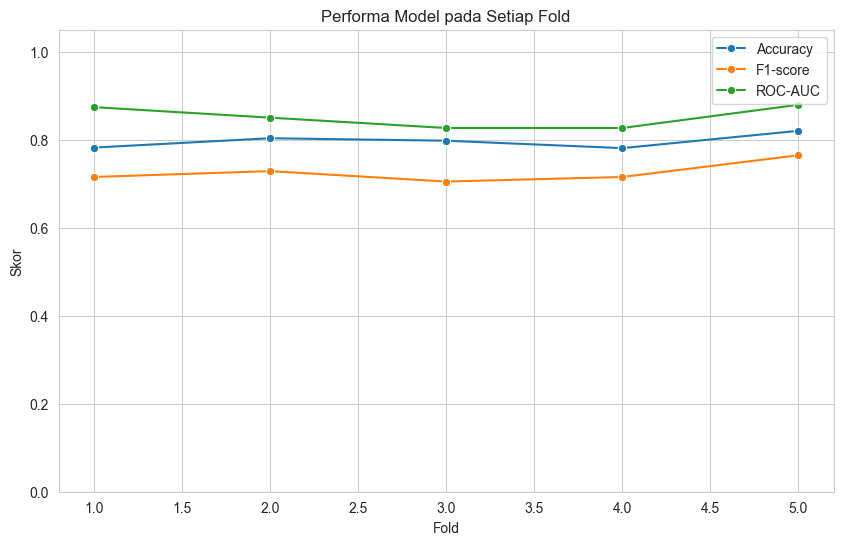

In [25]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=fold_df, x="Fold", y="Accuracy", marker="o", label="Accuracy")
sns.lineplot(data=fold_df, x="Fold", y="F1-score", marker="o", label="F1-score")
sns.lineplot(data=fold_df, x="Fold", y="ROC-AUC", marker="o", label="ROC-AUC")
plt.ylim(0, 1.05)
plt.title("Performa Model pada Setiap Fold")
plt.ylabel("Skor")
plt.show()

## 9. Classification Report pada Satu Fold Contoh

In [26]:
# Contoh classification report pada fold pertama
train_idx, test_idx = next(kf.split(X, y))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Not Survived", "Survived"]))

              precision    recall  f1-score   support

Not Survived       0.82      0.83      0.82       110
    Survived       0.72      0.71      0.72        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



## 10. Ringkasan Hasil

In [27]:
results_df = pd.DataFrame(
    fold_details,
    columns=["Fold", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "TN", "FP", "FN", "TP"]
)